This project analyzes employee burnout using machine learning. 
The objective is to identify key factors affecting burnout and 
build a predictive model to estimate burnout levels based on employee data.

Data Loading

In [1]:
import pandas as pd

df = pd.read_csv("../dataset/train.csv")

df.head()
df.shape
df.columns

Index(['Employee ID', 'Date of Joining', 'Gender', 'Company Type',
       'WFH Setup Available', 'Designation', 'Resource Allocation',
       'Mental Fatigue Score', 'Burn Rate'],
      dtype='str')

Data Cleaning & Preprocessing

In [2]:
df.isnull()
df.isnull().sum()

df = df.dropna(subset=["Burn Rate"])

df["Resource Allocation"] = df["Resource Allocation"].fillna(df["Resource Allocation"].mean())
df["Mental Fatigue Score"] = df["Mental Fatigue Score"].fillna(df["Mental Fatigue Score"].mean())

df = df.drop(["Employee ID","Date of Joining"], axis=1)

df["WFH Setup Available"] = df["WFH Setup Available"].map({"No":0,"Yes":1})
df["Company Type"] = df["Company Type"].map({"Service":0,"Product":1})

df["Gender"] = df["Gender"].str.strip().str.capitalize()
df["Gender"] = df["Gender"].map({"Male":0, "Female":1})

df.isnull().sum()
df.head()

,Gender,Company Type,WFH Setup Available,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate
0,1,0,0,2.0,3.000000,3.8,0.16
1,0,0,1,1.0,2.000000,5.0,0.36
2,1,1,1,2.0,4.483831,5.8,0.49
3,0,0,1,1.0,1.000000,2.6,0.20
4,1,0,0,3.0,7.000000,6.9,0.52


Exploratory Data Analysis (EDA)

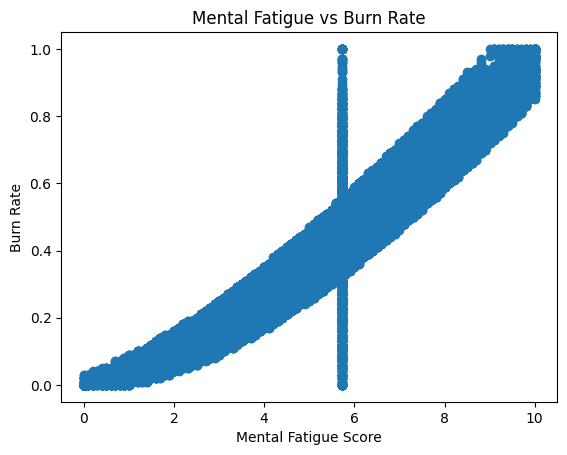

In [3]:
import matplotlib.pyplot as plt

plt.scatter(df["Mental Fatigue Score"], df["Burn Rate"])
plt.xlabel("Mental Fatigue Score")
plt.ylabel("Burn Rate")
plt.title("Mental Fatigue vs Burn Rate")
plt.show()

Heatmap

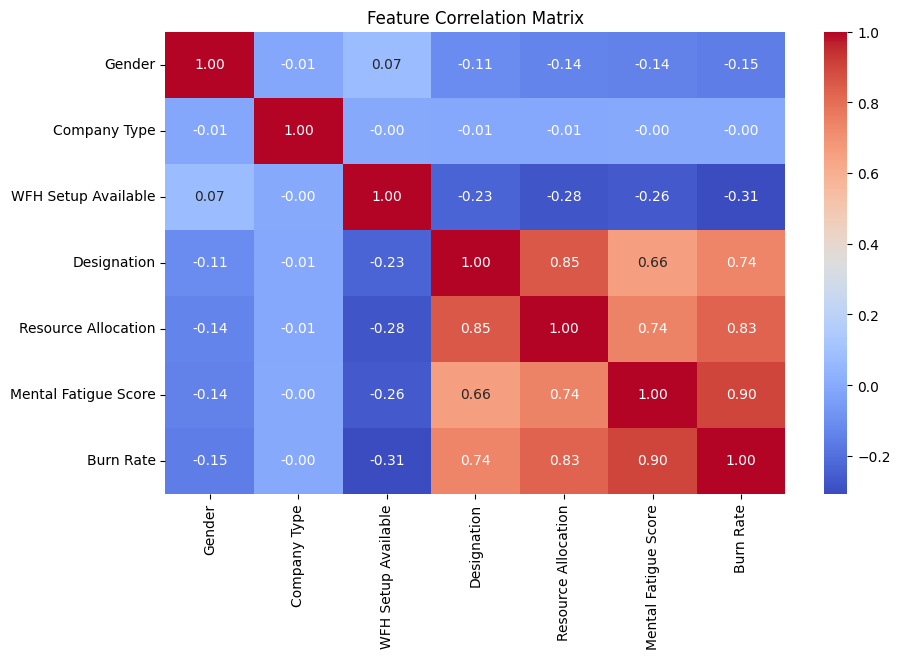

In [4]:
import seaborn as sns

corr = df.corr(numeric_only=True)
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()

Distribution

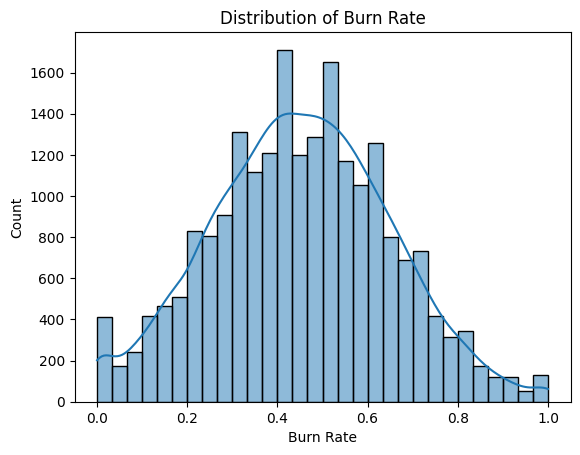

In [5]:
import seaborn as sns

sns.histplot(df["Burn Rate"], bins=30, kde=True)
plt.title("Distribution of Burn Rate")
plt.show()

Model Building

In [6]:
x = df.drop("Burn Rate", axis=1)
y = df["Burn Rate"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Model Evaluation

In [7]:
y_pred = model.predict(X_test)

from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R^2 Score:", r2)

Mean Squared Error: 0.005001519951461452
R^2 Score: 0.8686865822548381


Prediction Graph

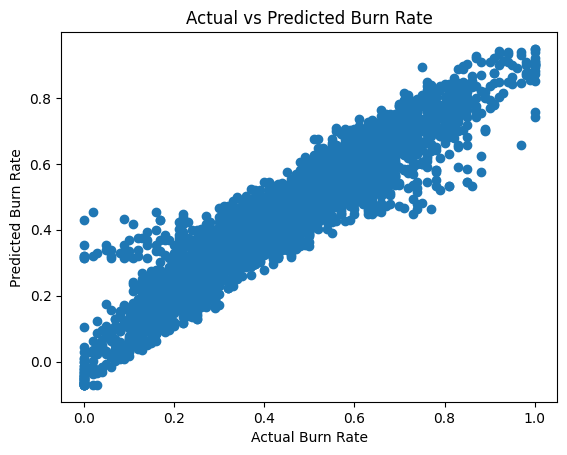

In [8]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Burn Rate")
plt.ylabel("Predicted Burn Rate")
plt.title("Actual vs Predicted Burn Rate")
plt.show()

The analysis shows that Mental Fatigue Score and Resource Allocation 
are key factors influencing employee burnout.

The Linear Regression model achieved an R² score of 0.86, indicating strong predictive performance.

This project demonstrates how machine learning can be used to 
predict burnout and help organizations take preventive measures.